# Violation Type Prediction

Predicts which violation type(s) a business is likely to be cited for at its next Routine Inspection, using only trailing (pre-inspection) history. Covers **all 53 distinct violation types** (full real-world coverage, not just the most common ones). Built as a standalone notebook - merge sections into `main.ipynb` as needed.

**Target**: multi-label - for each (inspection, candidate violation type) pair, was that type cited?

**Split**: chronological at 2025-09-05 (~80/20), Routine Inspections only, to avoid leakage.

**Output**: top-3 predicted violation types per inspection, evaluated with Precision@3 / Recall@3, gated by a predicted P(any violation) so clean businesses aren't force-fed 3 suggestions.

## Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
DATA_PATH = "final_completed.csv"
TOP_K = 53  # all distinct violation types - full coverage, not just the most common
TOP_N = 3  # how many violation types to suggest per inspection

## Feature Engineering

### Load data and pick the top-K violation types (by frequency, K=53 = all of them)

In [2]:
#only load routine inspections
def load_routine_inspections():
    global violation_description_table
    df = pd.read_csv(DATA_PATH, low_memory=False)
    df["Inspection Date"] = pd.to_datetime(df["Inspection Date"], errors="coerce")
    all_data_len=len(df)
    df = df[df["Inspection Type"] == "Routine Inspection/Field Review"].copy()

    df["Violation Description"] = df["Violation Description"].astype("category")
    violation_description_table = pd.Series(
        df["Violation Description"].cat.categories, name="full_description")
    
    print(f"There are {len(df)/all_data_len:.2%} of routine data")
    return df


#Extract the top N violation description
def get_top_violation_types(df, k=TOP_K):
    counts = df.dropna(subset=["Violation Description"])["Violation Description"].value_counts()
    return counts.head(k).index.tolist()

### Type-static features

`violation_type` (RED/BLUE) is a fixed attribute of each violation code (verified: all 53 codes map to exactly one type). `population_base_rate` is the citywide citation rate for each type, computed from **train data only** so it can't leak test-period popularity into the prior.

In [3]:
def violation_type_lookup(df, top_types):
    lookup = (df.dropna(subset=["Violation Description"])
                .drop_duplicates("Violation Description")
                .set_index("Violation Description")["Violation Type"])
    return lookup.reindex(top_types)

def population_base_rate(train_df, top_types):
    n_train_inspections = train_df["Inspection_Serial_Num"].nunique() #how many inspection do we have 
    viol = train_df.dropna(subset=["Violation Description"])
    #the count value for each violation
    citation_counts = (viol[viol["Violation Description"].isin(top_types)]
                        .drop_duplicates(["Inspection_Serial_Num", "Violation Description"]) 
                        ["Violation Description"].value_counts())
    return (citation_counts / n_train_inspections).reindex(top_types).fillna(0.0)

### Per-inspection index



In [4]:
#Get violations_cited and violation_points_sum
#violations_cited-> put all of the violation altogether in the same inspection
#violation_points_sum -> the inspection score(original data have sum them up so no need to sum again)
def build_inspection_index(df):
    base = (df.drop_duplicates("Inspection_Serial_Num")
              [["Business_ID", "Inspection_Serial_Num", "Inspection Date",
                "Inspection Score", "Inspection Result", "Classification",
                "Risk Category", "Seating Range"]])

    violations_cited = (df.dropna(subset=["Violation Description"])
                           .groupby("Inspection_Serial_Num")["Violation Description"]
                           .apply(set))

    total_points = df.groupby("Inspection_Serial_Num")["Violation Points"].sum()

    base = base.set_index("Inspection_Serial_Num")
    base["violations_cited"] = violations_cited.reindex(base.index).apply(
        lambda s: s if isinstance(s, set) else set())
    base["violation_points_sum"] = total_points.reindex(base.index).fillna(0)
    base = base.reset_index().sort_values(["Business_ID", "Inspection Date"])
    return base

### Business trailing features

For each inspection, compute history using **only prior inspections of that business** - `business_history_count` (all-time count per type) and `uncorrected_last_time` (was this type cited at the *immediately preceding* inspection - the strongest single signal, since 41.5% of the time an uncorrected violation carries into the next visit). State is updated *after* each row is recorded so no inspection ever sees its own outcome.

In [5]:
#use numpy arrays indexed by category code instead of a 53-key dict per row - much less memory
#history_arr:  how many times that violation type was cited across all of this business's past inspections
#uncorrected_rows: the violation happened in the last time inspection (binary)
#target_rows: the violation happened in this inspection
def business_trailing_features(insp_index, top_types):
    K = len(top_types)
    type_index = {v: i for i, v in enumerate(top_types)}

    business_ids, serials, dates = [], [], []
    classifications, risk_categories, seating_ranges = [], [], []
    days_since_last, num_prior, avg_score, avg_points, prior_results = [], [], [], [], []
    history_rows, uncorrected_rows, target_rows = [], [], []

    for biz_id, grp in insp_index.groupby("Business_ID"):
        grp = grp.sort_values("Inspection Date")
        history_count = np.zeros(K, dtype=np.int16)
        prev_cited = np.zeros(K, dtype=bool)
        prev_result = None
        prev_date = None
        scores, points = [], []

        for _, insp in grp.iterrows():
            cited_idx = [type_index[v] for v in insp["violations_cited"] if v in type_index]
            target_vec = np.zeros(K, dtype=bool)
            target_vec[cited_idx] = True

            business_ids.append(biz_id)
            serials.append(insp["Inspection_Serial_Num"])
            dates.append(insp["Inspection Date"])
            classifications.append(insp["Classification"])
            risk_categories.append(insp["Risk Category"])
            seating_ranges.append(insp["Seating Range"])
            days_since_last.append(
                (insp["Inspection Date"] - prev_date).days if prev_date is not None else None)
            num_prior.append(len(scores))
            avg_score.append(sum(scores) / len(scores) if scores else None)
            avg_points.append(sum(points) / len(points) if points else None)
            prior_results.append(prev_result)
            history_rows.append(history_count.copy())   # snapshot before this inspection
            uncorrected_rows.append(prev_cited.copy())
            target_rows.append(target_vec)

            history_count[cited_idx] += 1
            prev_cited = target_vec
            prev_result = insp["Inspection Result"]
            prev_date = insp["Inspection Date"]
            scores.append(insp["Inspection Score"])
            points.append(insp["violation_points_sum"])

    wide = pd.DataFrame({
        "Business_ID": business_ids, "Inspection_Serial_Num": serials, "Inspection Date": dates,
        "Classification": classifications, "Risk Category": risk_categories,
        "Seating Range": seating_ranges, "days_since_last_inspection": days_since_last,
        "num_prior_inspections": num_prior, "avg_historical_inspection_score": avg_score,
        "avg_historical_violation_points": avg_points, "prior_inspection_result": prior_results,
    })
    return wide, np.vstack(history_rows), np.vstack(uncorrected_rows), np.vstack(target_rows)


### Long format

Explode into one row per (inspection, candidate violation type) - this is what makes it a **single shared model** across all 53 types instead of 53 separate classifiers. `violation_type_candidate` itself is *not* used as a feature (the model should generalize via each type's properties - history, population rate, severity - not memorize a per-type identity).

In [6]:
#Flatten the data: 67,809 inspections x 53 violation types = 3,593,877 rows
#So each inspection has 53 rows, one per violation type 
#business_history_count_v = how many times this violation happened before this inspection (a count, not 0/1)
#uncorrected_last_time_v (0,1) = did this violation happen at the last inspection or not
#target (0,1) = did this violation actually happen in this inspection - what we're predicting
def to_long_format(wide, top_types, type_static, history_arr, uncorrected_arr, target_arr):
    N, K = history_arr.shape
    long_df = wide.loc[wide.index.repeat(K)].reset_index(drop=True)

    long_df["violation_type_candidate"] = pd.Categorical(np.tile(top_types, N))
    long_df["business_history_count_v"] = history_arr.ravel()
    long_df["uncorrected_last_time_v"] = uncorrected_arr.ravel()

    pop_rate = type_static["population_base_rate"].reindex(top_types).to_numpy()
    sev = type_static["violation_type"].reindex(top_types).to_numpy()
    long_df["population_base_rate_v"] = np.tile(pop_rate, N)
    long_df["violation_severity_v"] = pd.Categorical(np.tile(sev, N))
    long_df["target"] = target_arr.ravel().astype(int)
    return long_df


### Build the table

In [7]:
df = load_routine_inspections()
top_types = get_top_violation_types(df)
df = df.sort_values('Inspection Date')
split_idx = int(len(df) * 0.8)
train_raw = df.iloc[:split_idx]
type_static = {
    "violation_type": violation_type_lookup(df, top_types),
    "population_base_rate": population_base_rate(train_raw, top_types),
}

insp_index = build_inspection_index(df)
wide, history_arr, uncorrected_arr, target_arr = business_trailing_features(insp_index, top_types)

#history_arr/uncorrected_arr/target_arr line up with wide by ROW POSITION, not by any key
#so sorting/splitting wide must reorder all three arrays the same way, or rows get mismatched
order = wide["Inspection Date"].argsort().to_numpy()
wide = wide.iloc[order].reset_index(drop=True)
history_arr = history_arr[order]
uncorrected_arr = uncorrected_arr[order]
target_arr = target_arr[order]

#split by inspection count (80/20) instead of a fixed date - split at inspection level
#(one row = one inspection here) so a single inspection's violations never get split across train/test
wide_split_idx = int(len(wide) * 0.8)
wide["split"] = ["train"] * wide_split_idx + ["test"] * (len(wide) - wide_split_idx)

long_df = to_long_format(wide, top_types, type_static, history_arr, uncorrected_arr, target_arr)

print("Long-format table shape:", long_df.shape)
long_df["split"].value_counts()


There are 95.77% of routine data
Long-format table shape: (3593877, 18)


split
train    2875091
test      718786
Name: count, dtype: int64

In [8]:
long_df.head(2)

,Business_ID,Inspection_Serial_Num,Inspection Date,Classification,Risk Category,Seating Range,days_since_last_inspection,num_prior_inspections,avg_historical_inspection_score,avg_historical_violation_points,prior_inspection_result,split,violation_type_candidate,business_history_count_v,uncorrected_last_time_v,population_base_rate_v,violation_severity_v,target
0,PFE-PR-3134804,PFE-DACNRCO1W,2021-01-04,General Food Services,3.0,13-50,NaN,0,NaN,NaN,NaN,train,"3400 - Wiping cloths properly used, stored; sa...",0,False,0.102031,BLUE,0
1,PFE-PR-3134804,PFE-DACNRCO1W,2021-01-04,General Food Services,3.0,13-50,NaN,0,NaN,NaN,NaN,train,0600 - Adequate handwashing facilities,0,False,0.071831,RED,1


## Preprocessing for the model

First-inspection rows have no trailing history (all-NaN). Impute using **train-set statistics only**, and add `is_first_inspection` so the model can distinguish a genuine zero from a missing value.

In [9]:
NUMERIC_FEATURES = [
    "days_since_last_inspection", "num_prior_inspections",
    "avg_historical_inspection_score", "avg_historical_violation_points",
    "business_history_count_v", "population_base_rate_v",
]
CATEGORICAL_FEATURES = [
    "Classification", "Risk Category", "Seating Range",
    "prior_inspection_result", "violation_severity_v",
]
BOOL_FEATURES = ["uncorrected_last_time_v"]

def prepare(long_df):
    df = long_df.copy()
    df["is_first_inspection"] = (df["num_prior_inspections"] == 0).astype(int)
    train_mask = df["split"] == "train"

    #fill na value by mean 
    for col in ["avg_historical_inspection_score", "avg_historical_violation_points",
                "days_since_last_inspection"]:
        fill_val = df.loc[train_mask, col].mean()
        df[col] = df[col].fillna(fill_val)

    df["prior_inspection_result"] = df["prior_inspection_result"].fillna("No Prior Inspection")
    #Boolean to 0 and 1 
    df["uncorrected_last_time_v"] = df["uncorrected_last_time_v"].astype(int)

    df["Risk Category"] = df["Risk Category"].fillna(-1).astype(str)
    
    df["Seating Range"] = df["Seating Range"].fillna("Unknown")

    for col in ["violation_type_candidate", "Classification", "Risk Category",
                "Seating Range", "prior_inspection_result", "violation_severity_v"]:
        df[col] = df[col].astype("category")
    return df

def build_design_matrix(df, encoder=None, fit=False):
    numeric = df[NUMERIC_FEATURES + BOOL_FEATURES + ["is_first_inspection"]].to_numpy(dtype=float)
    if fit: #training
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        cat = encoder.fit_transform(df[CATEGORICAL_FEATURES])
    else:#testing 
        cat = encoder.transform(df[CATEGORICAL_FEATURES])
    return np.hstack([numeric, cat]), encoder

long_df = prepare(long_df)
train_df = long_df[long_df["split"] == "train"]
test_df = long_df[long_df["split"] == "test"]
print(f"Train rows: {len(train_df):,}  Test rows: {len(test_df):,}")
print("Target positive rate - train:", round(train_df['target'].mean(), 4),
      " test:", round(test_df['target'].mean(), 4))

Train rows: 2,875,091  Test rows: 718,786
Target positive rate - train: 0.0183  test: 0.0176


## Build design matrices

In [10]:
X_train, encoder = build_design_matrix(train_df, fit=True)
y_train = train_df["target"].to_numpy()
X_test, _ = build_design_matrix(test_df, encoder=encoder, fit=False)
y_test = test_df["target"].to_numpy()

feature_names = (NUMERIC_FEATURES + BOOL_FEATURES + ["is_first_inspection"]
                  + list(encoder.get_feature_names_out(CATEGORICAL_FEATURES)))

## Evaluation helpers: Precision@N / Recall@N

For each inspection, rank the 53 candidates by predicted probability. `P(any) = 1 - ∏(1-p_v)` combines them into "is this inspection likely to have any violation at all" - used as a gate so clean businesses aren't force-fed a top-3 list. The gate threshold is picked on **train data** (maximizing F1 for "has any violation"), not eyeballed - a flat 0.5 turned out to fire on essentially every inspection, since P(any) naturally hovers near the population base rate.

In [11]:
def per_inspection_scores(df, probs):
    df = df.copy()
    df["pred_prob"] = probs
    rows = []
    for serial, grp in df.groupby("Inspection_Serial_Num"):
        grp = grp.sort_values("pred_prob", ascending=False)
        #generate the violation probability
        p_any = 1 - np.prod(1 - grp["pred_prob"].to_numpy())
        actual_types = set(grp.loc[grp["target"] == 1, "violation_type_candidate"])
        rows.append({
            "Inspection_Serial_Num": serial,
            "p_any": p_any,
            "n_actual": len(actual_types),
            "top3": set(grp.head(TOP_N)["violation_type_candidate"]),
            "actual_types": actual_types,
        })
    return pd.DataFrame(rows)

def evaluate(scores, gate_threshold):
    fires = scores["p_any"] >= gate_threshold
    predicted = np.where(fires, scores["top3"], [set()] * len(scores))
    n_correct = [len(p & a) for p, a in zip(predicted, scores["actual_types"])]
    n_predicted = [len(p) for p in predicted]
    n_actual = scores["n_actual"].to_numpy()

    precision = sum(n_correct) / sum(n_predicted) if sum(n_predicted) else float("nan")
    recall = sum(n_correct) / sum(n_actual) if sum(n_actual) else float("nan")
    return scores.assign(n_predicted=n_predicted, n_correct=n_correct), precision, recall

#pick threshold by maximizing F1 of the actual Precision@3/Recall@3 we report,
#not a simpler "any violation y/n" proxy - reuse evaluate() at each candidate threshold
def pick_gate_threshold(train_scores):
    thresholds = np.quantile(train_scores["p_any"], np.linspace(0.05, 0.95, 37))
    best_t, best_f1 = thresholds[0], -1
    for t in thresholds:
        _, precision, recall = evaluate(train_scores, t)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

#Youden's J = TPR - FPR (catch_rate - false_alarm_rate), a standard existing
#diagnostic-testing method (Youden 1950) for balancing sensitivity/specificity,
#using sklearn's roc_curve rather than a custom search
def pick_gate_threshold_youden(train_scores):
    y_true = (train_scores["n_actual"] > 0).astype(int)
    fpr, tpr, thresholds = roc_curve(y_true, train_scores["p_any"])
    return thresholds[np.argmax(tpr - fpr)]

PICK_THRESHOLD = {"f1": pick_gate_threshold, "youden": pick_gate_threshold_youden}


## Models: Logistic Regression vs Random Forest vs XGBoost

Same design matrix, same evaluation, two models. Neither uses `class_weight="balanced"` - that distorts `predict_proba` away from true probabilities, which matters since we combine per-type probabilities into P(any violation).

In [12]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def run_model(name, clf, threshold_method="f1"):
    clf.fit(X_train, y_train)
    train_probs = clf.predict_proba(X_train)[:, 1]
    test_probs = clf.predict_proba(X_test)[:, 1]

    #train score
    train_scores = per_inspection_scores(train_df, train_probs)
    gate_threshold = PICK_THRESHOLD[threshold_method](train_scores)

    #test score
    test_scores = per_inspection_scores(test_df, test_probs)

    per_inspection, precision, recall = evaluate(test_scores, gate_threshold)

    # f1 score
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
    #no any violation
    clean = per_inspection[per_inspection["n_actual"] == 0]

    #violation
    dirty = per_inspection[per_inspection["n_actual"] > 0]

    false_alarm_rate = (clean["n_predicted"] > 0).mean()
    catch_rate = (dirty["n_predicted"] > 0).mean()

    return clf, {
        "model": name,
        "gate_threshold": gate_threshold,
        "precision@3": precision,
        "recall@3": recall,
        "f1@3": f1,
        "false_alarm_rate": false_alarm_rate,
        "catch_rate": catch_rate,
        "youden_j": catch_rate - false_alarm_rate,  # TPR - FPR at this threshold
    }


### Logistic Regression

In [13]:
lr_clf, lr_result = run_model("Logistic Regression", LogisticRegression(max_iter=3000))

### Random Forest with hyper-parameter tuning

A small search over `n_estimators` and `max_depth` on a validation split (not full CV, given the data size) - based on earlier testing, don't expect a big jump in the gate's AUC, this is mainly to confirm the current defaults are reasonable rather than to chase a large improvement.

In [14]:
from sklearn.metrics import log_loss

#internal validation split - last 20% of TRAIN chronologically, never touches the real test set
split_idx = int(len(train_df) * 0.8)
fit_df = train_df.iloc[:split_idx]
val_df = train_df.iloc[split_idx:]

X_fit, encoder_fit = build_design_matrix(fit_df, fit=True)
y_fit = fit_df["target"].to_numpy()
X_val, _ = build_design_matrix(val_df, encoder=encoder_fit, fit=False)
y_val = val_df["target"].to_numpy()

rf_param_grid = [
    {"n_estimators": 300, "max_depth": 12},
    {"n_estimators": 300, "max_depth": 16},
    {"n_estimators": 600, "max_depth": 12},
    {"n_estimators": 600, "max_depth": 16},
]



best_loss, best_rf_params = float("inf"), None
for params in rf_param_grid:
    clf = RandomForestClassifier(min_samples_leaf=20, n_jobs=-1, random_state=0, **params)
    clf.fit(X_fit, y_fit)
    loss = log_loss(y_val, clf.predict_proba(X_val)[:, 1])
    print(f"{params} -> val log loss: {loss:.4f}")
    if loss < best_loss:
        best_loss, best_rf_params = loss, params

print(f"\nBest: {best_rf_params} (val log loss={best_loss:.4f})")

{'n_estimators': 300, 'max_depth': 12} -> val log loss: 0.0742
{'n_estimators': 300, 'max_depth': 16} -> val log loss: 0.0738
{'n_estimators': 600, 'max_depth': 12} -> val log loss: 0.0742
{'n_estimators': 600, 'max_depth': 16} -> val log loss: 0.0737

Best: {'n_estimators': 600, 'max_depth': 16} (val log loss=0.0737)


In [15]:
rf_clf, rf_result = run_model("Random Forest", RandomForestClassifier(
    min_samples_leaf=20, n_jobs=-1, random_state=0, **best_rf_params))


### XGBoost with hyper-parameter tuning

Same validation split as the Random Forest search above, reusing `X_fit`/`X_val`/`y_fit`/`y_val`. A small grid over `max_depth` and `learning_rate`, scored on validation log loss (calibration-aware, not just ranking - matters here since `P(any)` multiplies these probabilities together).

In [16]:
xgb_param_grid = [
    {"max_depth": 6, "learning_rate": 0.1},
    {"max_depth": 6, "learning_rate": 0.05},
    {"max_depth": 8, "learning_rate": 0.1},
    {"max_depth": 8, "learning_rate": 0.05},
]

best_xgb_loss, best_xgb_params = float("inf"), None
for params in xgb_param_grid:
    clf = XGBClassifier(n_estimators=500, eval_metric="logloss", n_jobs=-1, random_state=0, **params)
    clf.fit(X_fit, y_fit)
    loss = log_loss(y_val, clf.predict_proba(X_val)[:, 1])
    print(f"{params} -> val log loss: {loss:.4f}")
    if loss < best_xgb_loss:
        best_xgb_loss, best_xgb_params = loss, params

print(f"\nBest: {best_xgb_params} (val log loss={best_xgb_loss:.4f})")

{'max_depth': 6, 'learning_rate': 0.1} -> val log loss: 0.0737
{'max_depth': 6, 'learning_rate': 0.05} -> val log loss: 0.0732
{'max_depth': 8, 'learning_rate': 0.1} -> val log loss: 0.0748
{'max_depth': 8, 'learning_rate': 0.05} -> val log loss: 0.0736

Best: {'max_depth': 6, 'learning_rate': 0.05} (val log loss=0.0732)


In [17]:
xgb_clf, xgb_result = run_model("XGBoost", XGBClassifier(
    n_estimators=500, eval_metric="logloss", n_jobs=-1, random_state=0, **best_xgb_params))


### Result and ROC curve for the P(any) gate

This is specifically about the gate's binary decision ("is this inspection at-risk at all"), not the top-3 ranking quality itself - it's what F1-optimized and Youden's J are each picking a single point from, shown here as the full curve (on **train data**, since that's what the threshold is actually chosen from).

In [18]:
comparison = pd.DataFrame([lr_result, rf_result, xgb_result]).set_index("model")
comparison.round(3)

,gate_threshold,precision@3,recall@3,f1@3,false_alarm_rate,catch_rate,youden_j
model,,,,,,,
Logistic Regression,0.595,0.145,0.197,0.167,0.256,0.614,0.358
Random Forest,0.585,0.151,0.223,0.180,0.284,0.658,0.373
XGBoost,0.616,0.165,0.202,0.182,0.213,0.572,0.358


In [19]:
#recompute train_scores from the already-fitted classifiers - run_model() only keeps these local
lr_train_scores = per_inspection_scores(train_df, lr_clf.predict_proba(X_train)[:, 1])
rf_train_scores = per_inspection_scores(train_df, rf_clf.predict_proba(X_train)[:, 1])
xgb_train_scores = per_inspection_scores(train_df, xgb_clf.predict_proba(X_train)[:, 1])

def roc_for(train_scores):
    y_true = (train_scores["n_actual"] > 0).astype(int)
    fpr, tpr, thresholds = roc_curve(y_true, train_scores["p_any"])
    auc = roc_auc_score(y_true, train_scores["p_any"])
    return fpr, tpr, thresholds, auc


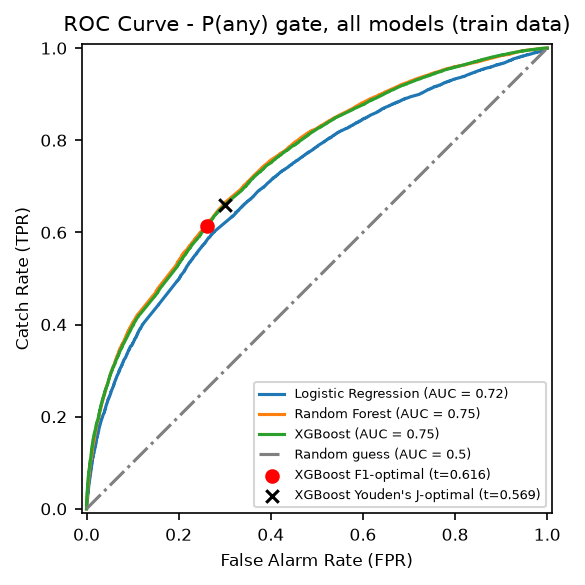

In [20]:

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
for name, train_scores, color in [
    ("Logistic Regression", lr_train_scores, "tab:blue"),
    ("Random Forest", rf_train_scores, "tab:orange"),
    ("XGBoost", xgb_train_scores, "tab:green"),
]:
    fpr, tpr, thresholds, auc = roc_for(train_scores)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, name=name).plot(
        ax=ax, curve_kwargs={"color": color})

#diagonal reference line for a random classifier (AUC = 0.5)
ax.plot([0, 1], [0, 1], linestyle="-.", color="gray", label="Random guess (AUC = 0.5)")

#mark XGBoost's two chosen thresholds on its own curve
xgb_fpr, xgb_tpr, xgb_thresholds, _ = roc_for(xgb_train_scores)
f1_threshold = pick_gate_threshold(xgb_train_scores)
youden_threshold = pick_gate_threshold_youden(xgb_train_scores)
f1_idx = np.argmin(np.abs(xgb_thresholds - f1_threshold))
youden_idx = np.argmin(np.abs(xgb_thresholds - youden_threshold))
ax.scatter(xgb_fpr[f1_idx], xgb_tpr[f1_idx], color="red", zorder=5,
           label=f"XGBoost F1-optimal (t={f1_threshold:.3f})")
ax.scatter(xgb_fpr[youden_idx], xgb_tpr[youden_idx], color="black", marker="x", zorder=5,
           label=f"XGBoost Youden's J-optimal (t={youden_threshold:.3f})")

ax.set_xlabel("False Alarm Rate (FPR)", fontsize=8)
ax.set_ylabel("Catch Rate (TPR)", fontsize=8)
ax.set_title("ROC Curve - P(any) gate, all models (train data)", fontsize=10)
ax.tick_params(labelsize=8)
ax.set_aspect("equal", adjustable="box")  # keeps the curve undistorted even though the figure is wide
ax.legend(fontsize=6)  # legend uses the extra width, not the plot
plt.tight_layout()
plt.show()

### Random Forest feature importances

Which features actually drive the stronger model's predictions.

In [21]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15)

population_base_rate_v                    0.313957
uncorrected_last_time_v                   0.185717
business_history_count_v                  0.168263
avg_historical_inspection_score           0.072892
days_since_last_inspection                0.066827
avg_historical_violation_points           0.066064
num_prior_inspections                     0.028569
prior_inspection_result_Unsatisfactory    0.013077
prior_inspection_result_Satisfactory      0.008988
Risk Category_3.0                         0.007701
Classification_General Food Services      0.007424
violation_severity_v_BLUE                 0.007138
violation_severity_v_RED                  0.006893
Seating Range_Unknown                     0.006426
Seating Range_0-12                        0.006194
dtype: float64

## Baselines

How much is the model actually learning, vs. just reflecting how common each violation type is? Two baselines, evaluated the same way: (1) randomly pick 3 of the 53 candidates, (2) always suggest the 3 most globally common types, with no personalization at all.

In [23]:
def baseline_scores(picks_fns):
    correct = {name: 0 for name in picks_fns}
    predicted = {name: 0 for name in picks_fns}
    actual = 0
    for _, grp in test_df.groupby("Inspection_Serial_Num"):
        actual_types = set(grp.loc[grp["target"] == 1, "violation_type_candidate"])
        actual += len(actual_types)
        for name, picks_fn in picks_fns.items():
            picks = picks_fn(grp)
            correct[name] += len(picks & actual_types)
            predicted[name] += len(picks)
    return {name: (correct[name] / predicted[name], correct[name] / actual) for name in picks_fns}

rng = np.random.default_rng(0)
top3_popular = set(type_static["population_base_rate"].sort_values(ascending=False).head(TOP_N).index)

results = baseline_scores({
    f"Random {TOP_N}-of-{TOP_K}": lambda grp: set(rng.choice(grp["violation_type_candidate"].to_numpy(), size=TOP_N, replace=False)),
    f"Always top-{TOP_N} most common": lambda grp: top3_popular,
})

baselines = pd.DataFrame([
    {"model": name, "precision@3": p, "recall@3": r,
     "f1@3": 2 * p * r / (p + r) if (p + r) else float("nan")}
    for name, (p, r) in results.items()
]).set_index("model")

pd.concat([baselines, comparison[["precision@3", "recall@3", "f1@3"]]]).round(3)

,precision@3,recall@3,f1@3
model,,,
Random 3-of-53,0.017,0.056,0.027
Always top-3 most common,0.067,0.215,0.102
Logistic Regression,0.145,0.197,0.167
Random Forest,0.151,0.223,0.180
XGBoost,0.165,0.202,0.182


## Notes / next steps

- Scoped to **all 53 violation types**, not just the most common ones - full real-world coverage, at the cost of a harder prediction problem (more candidates to rank correctly).
  
- **Random Forest** clearly beats both baselines: Precision@3 of 0.151 is roughly **8.9x random guessing** and **~2.3x the naive "always suggest the most common violations"** baseline, and it has the best recall/catch-rate (0.223 / 0.658) of the three models.
  
- **XGBoost**, tuned via a small `max_depth`/`learning_rate` search on validation log loss (calibration-aware, since `P(any)` multiplies these probabilities together), has the best overall F1@3 (0.182) - highest Precision@3 (0.165, ~9.7x random guessing and ~2.5x the popularity baseline) and lowest false-alarm rate (0.213), trading away some recall/catch-rate compared to Random Forest.
  
- Possible next steps: Revisit the P(any) gate threshold with a precision/recall trade-off the health department would actually want, or try a dedicated binary classifier trained directly on "any violation" instead of deriving the gate from the 53 per-type probabilities (the current aggregation caps gate AUC around 0.75 even though row-level AUC reaches ~0.85).